<a href="https://colab.research.google.com/github/pragatikorde009-pixel/OIBSIS/blob/main/customer_segmentation_basket_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using K-Means (RFM Analysis)
**Dataset:** `basket_details.csv` (customer_id, product_id, basket_date, basket_count) and `customer_details.csv`.
**Note:** this dataset has no price column, so **Monetary is measured as total items purchased** (basket_count) instead of currency.
**Stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

# ---- CONFIG ----
BASKET_PATH = "basket_details.csv"      # in Colab these sit in /content, so the plain file name works
CUSTOMER_PATH = "customer_details.csv"
RANDOM_STATE = 42

## 1. Load data and inspect structure

In [ ]:
basket = pd.read_csv(BASKET_PATH)
customers = pd.read_csv(CUSTOMER_PATH)

print("basket_details shape  :", basket.shape)
print("customer_details shape:", customers.shape)
print("\nbasket columns   :", list(basket.columns))
print("customer columns :", list(customers.columns))
display(basket.head())
display(customers.head())

basket_details shape  : (15000, 4)
customer_details shape: (20000, 4)

basket columns   : ['customer_id', 'product_id', 'basket_date', 'basket_count']
customer columns : ['customer_id', 'sex', 'customer_age', 'tenure']


,customer_id,product_id,basket_date,basket_count
0,42366585,41475073,2019-06-19,2
1,35956841,43279538,2019-06-19,2
2,26139578,31715598,2019-06-19,3
3,3262253,47880260,2019-06-19,2
4,20056678,44747002,2019-06-19,2


,customer_id,sex,customer_age,tenure
0,9798859,Male,44.0,93
1,11413563,Male,36.0,65
2,818195,Male,35.0,129
3,12049009,Male,33.0,58
4,10083045,Male,42.0,88


In [ ]:
print("basket_details dtypes:"); print(basket.dtypes)
print("\ncustomer_details dtypes:"); print(customers.dtypes)
print("\nMissing values (basket):"); print(basket.isnull().sum())
print("\nMissing values (customers):"); print(customers.isnull().sum())
print("\nDuplicate rows -> basket:", basket.duplicated().sum(), "| customers:", customers.duplicated().sum())
print("Basket rows with basket_count <= 0:", (basket["basket_count"] <= 0).sum())
print("Unique customers in basket data:", basket["customer_id"].nunique())

basket_details dtypes:
customer_id      int64
product_id       int64
basket_date     object
basket_count     int64
dtype: object

customer_details dtypes:
customer_id       int64
sex              object
customer_age    float64
tenure            int64
dtype: object

Missing values (basket):
customer_id     0
product_id      0
basket_date     0
basket_count    0
dtype: int64

Missing values (customers):
customer_id     0
sex             0
customer_age    0
tenure          0
dtype: int64

Duplicate rows -> basket: 0 | customers: 0
Basket rows with basket_count <= 0: 0
Unique customers in basket data: 13871


**Observations:**
- `basket_details` has _X_ rows and `customer_details` has _Y_ rows.
- Missing values found: _..._ ; duplicate rows: _..._ ; invalid basket counts: _..._
- `basket_date` is stored as text and needs converting to datetime.

## 2. Data cleaning

In [ ]:
before = len(basket)

basket = basket.dropna(subset=["customer_id", "basket_date", "basket_count"])
basket = basket.drop_duplicates()
basket = basket[basket["basket_count"] > 0]                      # remove invalid quantities
basket["basket_date"] = pd.to_datetime(basket["basket_date"], errors="coerce")
basket = basket.dropna(subset=["basket_date"])                   # drop unparseable dates

customers = customers.drop_duplicates(subset="customer_id")      # one row per customer

print(f"basket rows: {before:,} -> {len(basket):,} after cleaning")
print("Date range:", basket["basket_date"].min().date(), "to", basket["basket_date"].max().date())
print("Customers:", basket["customer_id"].nunique())

basket rows: 15,000 -> 15,000 after cleaning
Date range: 2019-05-20 to 2019-06-19
Customers: 13871


**Note:** I removed rows with missing values, exact duplicates, non-positive basket counts and unparseable dates, and kept one row per customer in `customer_details`. _(Mention how many rows were removed.)_

## 3. Descriptive statistics: purchase value, frequency, lifetime value

Average purchase size (items per basket): 2.15
Median / mode purchase size              : 2.0 / 2
Average purchase frequency               : 1.08 purchases per customer
Median purchase frequency                : 1

Historical CLV (avg total items per customer): 2.33
Simple formula CLV (items over 12 months)     : 27.95


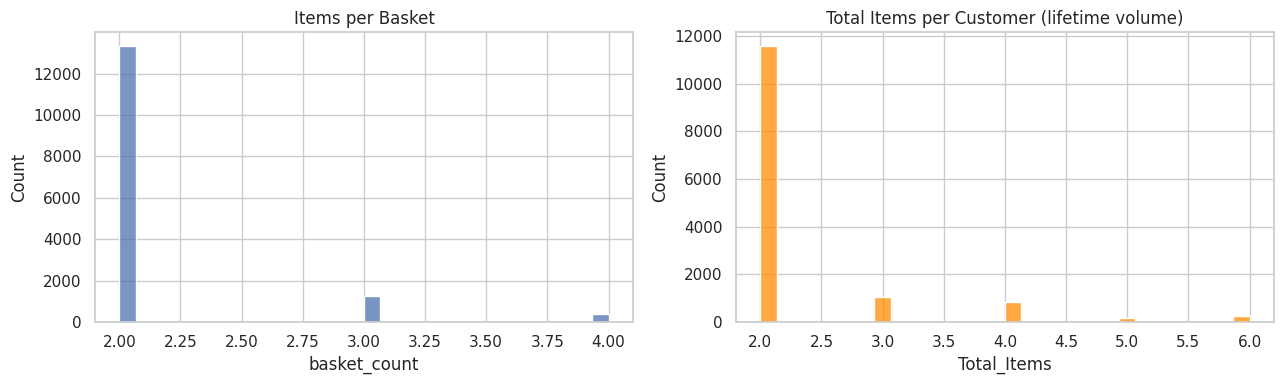

In [ ]:
# No price column -> "purchase value" = items per basket (basket_count)
avg_basket = basket["basket_count"].mean()
med_basket = basket["basket_count"].median()
mode_basket = basket["basket_count"].mode().iloc[0]

per_cust = basket.groupby("customer_id").agg(
    Purchases=("basket_date", "size"),
    Total_Items=("basket_count", "sum"),
)
print(f"Average purchase size (items per basket): {avg_basket:.2f}")
print(f"Median / mode purchase size              : {med_basket:.1f} / {mode_basket}")
print(f"Average purchase frequency               : {per_cust['Purchases'].mean():.2f} purchases per customer")
print(f"Median purchase frequency                : {per_cust['Purchases'].median():.0f}")

# Customer Lifetime Value (volume-based, since price is unavailable)
span_months = max((basket["basket_date"].max() - basket["basket_date"].min()).days / 30, 1)
freq_per_month = per_cust["Purchases"].mean() / span_months
LIFESPAN_MONTHS = 12
simple_clv_items = avg_basket * freq_per_month * LIFESPAN_MONTHS

print(f"\nHistorical CLV (avg total items per customer): {per_cust['Total_Items'].mean():.2f}")
print(f"Simple formula CLV (items over {LIFESPAN_MONTHS} months)     : {simple_clv_items:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(basket["basket_count"].clip(upper=basket["basket_count"].quantile(0.99)), bins=30, ax=ax[0])
ax[0].set_title("Items per Basket")
sns.histplot(per_cust["Total_Items"].clip(upper=per_cust["Total_Items"].quantile(0.99)), bins=30, ax=ax[1], color="darkorange")
ax[1].set_title("Total Items per Customer (lifetime volume)")
plt.tight_layout(); plt.show()

**Observations:**
- Average basket size is _..._ items (median _..._).
- The average customer makes _..._ purchases; _..._% of customers purchased only once.
- Lifetime value is measured in items (no prices available); the spread between customers is _..._

## 4. Feature selection: RFM

- **Recency:** days since the customer's last basket (lower is better)
- **Frequency:** number of purchases (baskets) made
- **Monetary:** total items purchased (`basket_count` summed), used as the spend proxy because there is no price

In [ ]:
snapshot = basket["basket_date"].max() + pd.Timedelta(days=1)

rfm = basket.groupby("customer_id").agg(
    Recency=("basket_date", lambda x: (snapshot - x.max()).days),
    Frequency=("basket_date", "size"),
    Monetary=("basket_count", "sum"),
    Unique_Products=("product_id", "nunique"),
)
display(rfm.head())
display(rfm.describe().round(2))

print("Distinct Frequency values:", rfm["Frequency"].nunique())
print(rfm["Frequency"].value_counts().head(8))

,Recency,Frequency,Monetary,Unique_Products
customer_id,,,,
4784,24,1,2,1
8314,26,2,5,2
8857,26,1,2,1
9273,13,1,2,1
11172,12,1,2,1


,Recency,Frequency,Monetary,Unique_Products
count,13871.00,13871.00,13871.00,13871.00
mean,18.69,1.08,2.33,1.08
std,8.55,0.34,0.97,0.33
min,1.00,1.00,2.00,1.00
25%,11.00,1.00,2.00,1.00
50%,23.00,1.00,2.00,1.00
75%,25.00,1.00,2.00,1.00
max,31.00,8.00,29.00,8.00


Distinct Frequency values: 7
Frequency
1    12934
2      801
3       99
4       25
5        9
8        2
6        1
Name: count, dtype: int64


Features used for clustering: ['Recency', 'Frequency', 'Monetary']


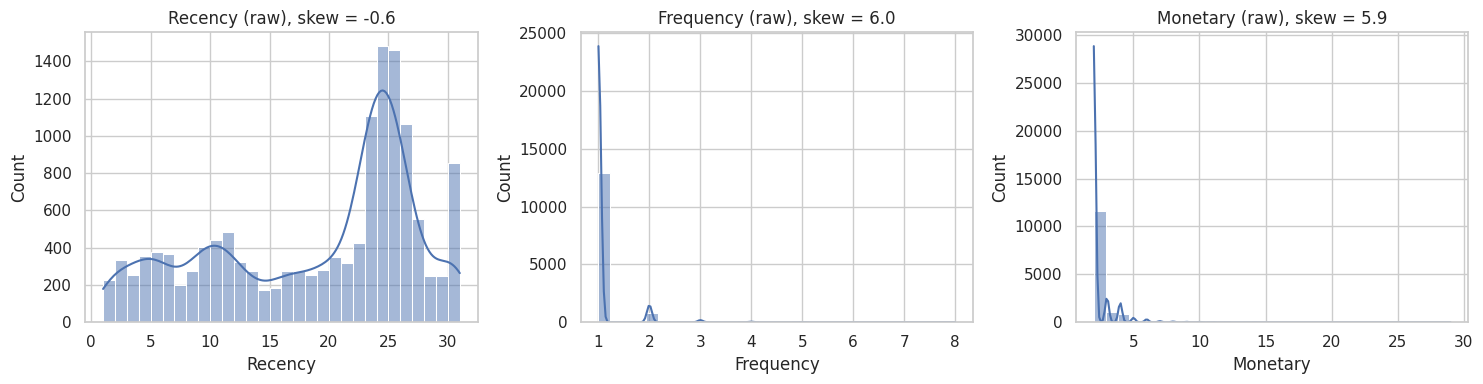

In [ ]:
# If almost every customer has the same Frequency, it can't separate customers.
# In that case, use Unique_Products (variety of products bought) as the second feature.
FEATURES = ["Recency", "Frequency", "Monetary"]
if rfm["Frequency"].nunique() < 5:
    FEATURES = ["Recency", "Unique_Products", "Monetary"]
    print("Frequency has very little variation -> using Unique_Products instead.")
print("Features used for clustering:", FEATURES)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, FEATURES):
    sns.histplot(rfm[col], bins=30, ax=a, kde=True)
    a.set_title(f"{col} (raw), skew = {rfm[col].skew():.1f}")
plt.tight_layout(); plt.show()

**Observation:** _Describe the shape of each feature. If they are right-skewed, a log transform helps before scaling._

## 5. Standardisation

In [ ]:
rfm_log = np.log1p(rfm[FEATURES])          # reduce skew
X = StandardScaler().fit_transform(rfm_log)
print("Scaled means (~0):", np.round(X.mean(axis=0), 3))
print("Scaled stds  (~1):", np.round(X.std(axis=0), 3))

Scaled means (~0): [-0. -0.  0.]
Scaled stds  (~1): [1. 1. 1.]


**Note:** K-Means is distance based, so features must be on the same scale, otherwise the feature with the largest numbers dominates.

## 6. K-Means and the Elbow Method

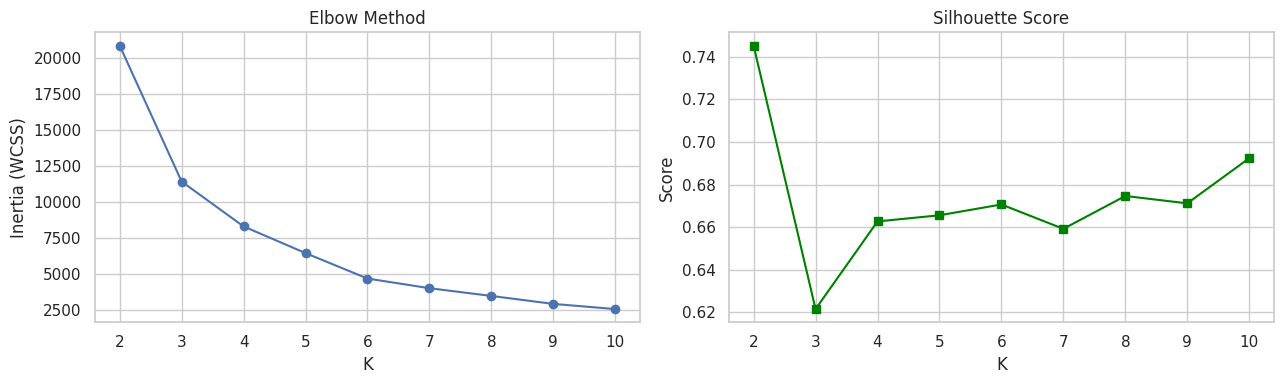

    K  Inertia  Silhouette
0   2  20833.2       0.745
1   3  11419.5       0.622
2   4   8314.0       0.663
3   5   6467.1       0.666
4   6   4706.7       0.671
5   7   4037.6       0.659
6   8   3501.5       0.675
7   9   2950.5       0.671
8  10   2592.9       0.692


In [ ]:
K_RANGE = range(2, 11)
inertia, sil = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels, sample_size=min(5000, len(X)), random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(K_RANGE), inertia, marker="o")
ax[0].set_title("Elbow Method"); ax[0].set_xlabel("K"); ax[0].set_ylabel("Inertia (WCSS)")
ax[1].plot(list(K_RANGE), sil, marker="s", color="green")
ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("K"); ax[1].set_ylabel("Score")
plt.tight_layout(); plt.show()
print(pd.DataFrame({"K": list(K_RANGE), "Inertia": np.round(inertia, 1), "Silhouette": np.round(sil, 3)}))

**Observation:** The elbow appears around **K = _..._** where the inertia curve flattens, and the silhouette score is _..._ there.

In [ ]:
OPTIMAL_K = 4   # <-- set to the elbow you observed

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)
print("Final silhouette:", round(silhouette_score(X, rfm["Cluster"], sample_size=min(5000, len(X)), random_state=RANDOM_STATE), 3))
rfm["Cluster"].value_counts().sort_index()

Final silhouette: 0.663


,count
Cluster,
0,8550
1,937
2,3201
3,1183


## 7. Cluster visualisation

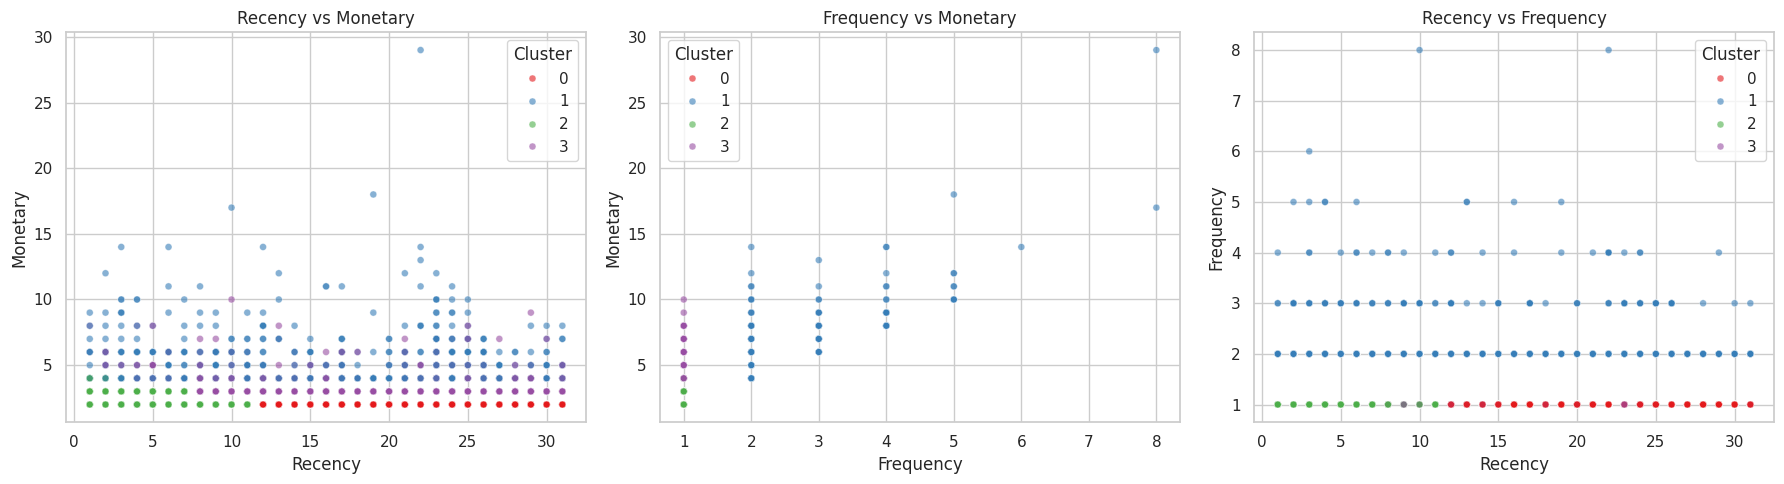

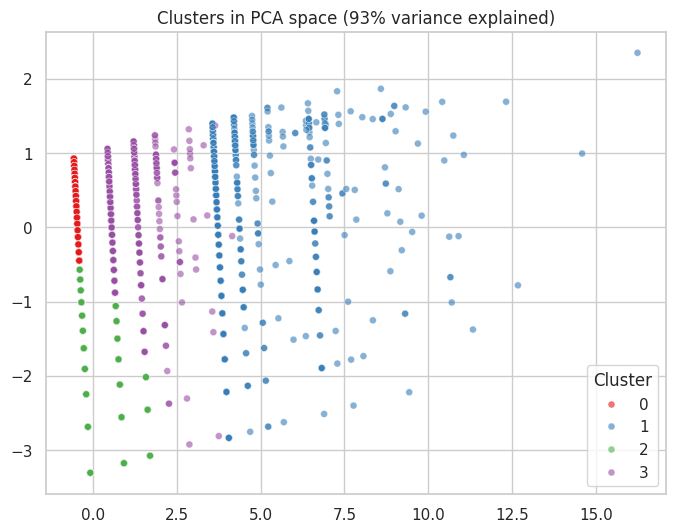

In [ ]:
palette = sns.color_palette("Set1", OPTIMAL_K)
f1, f2, f3 = FEATURES

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, (x, y) in zip(ax, [(f1, f3), (f2, f3), (f1, f2)]):
    sns.scatterplot(data=rfm, x=x, y=y, hue="Cluster", palette=palette, alpha=0.6, s=25, ax=a)
    a.set_title(f"{x} vs {y}")
plt.tight_layout(); plt.show()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
comp = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=comp[:, 0], y=comp[:, 1], hue=rfm["Cluster"], palette=palette, alpha=0.6, s=25)
plt.title(f"Clusters in PCA space ({pca.explained_variance_ratio_.sum():.0%} variance explained)")
plt.show()

**Observations:**
- **Recency vs Monetary:** _..._
- **Frequency vs Monetary:** _..._
- The PCA view shows the clusters are _well separated / overlapping_.

## 8. Cluster profiling

In [ ]:
profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary_Items=("Monetary", "mean"),
    Avg_Unique_Products=("Unique_Products", "mean"),
    Total_Items=("Monetary", "sum"),
).round(1)
profile["Pct_Customers"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile["Pct_Volume"] = (profile["Total_Items"] / profile["Total_Items"].sum() * 100).round(1)

def label(row):
    r_good = row["Avg_Recency"] <= profile["Avg_Recency"].median()
    f_good = row["Avg_Frequency"] >= profile["Avg_Frequency"].median()
    m_good = row["Avg_Monetary_Items"] >= profile["Avg_Monetary_Items"].median()
    if r_good and f_good and m_good: return "Champions / Loyal"
    if r_good and not f_good:        return "New / Promising"
    if not r_good and (f_good or m_good): return "At Risk"
    if not r_good:                   return "Lost / Hibernating"
    return "Potential Loyalists"

profile["Suggested_Segment"] = profile.apply(label, axis=1)
profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary_Items,Avg_Unique_Products,Total_Items,Pct_Customers,Pct_Volume,Suggested_Segment
Cluster,,,,,,,,,
0,8550,23.2,1.0,2.0,1.0,17100,61.6,52.9,At Risk
1,937,16.5,2.2,4.9,2.2,4607,6.8,14.3,Champions / Loyal
2,3201,6.4,1.0,2.1,1.0,6592,23.1,20.4,Potential Loyalists
3,1183,21.2,1.0,3.4,1.0,4007,8.5,12.4,At Risk


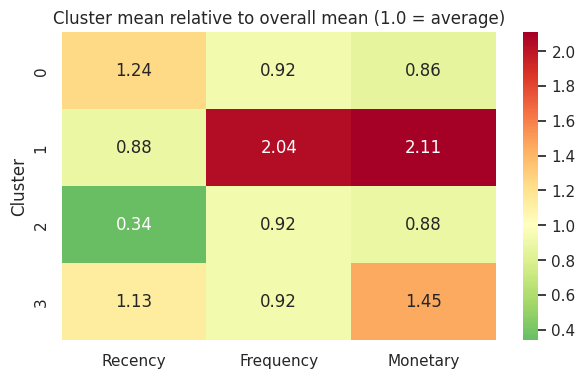

In [ ]:
rel = rfm.groupby("Cluster")[FEATURES].mean() / rfm[FEATURES].mean()
plt.figure(figsize=(7, 4))
sns.heatmap(rel, annot=True, fmt=".2f", cmap="RdYlGn_r", center=1)
plt.title("Cluster mean relative to overall mean (1.0 = average)")
plt.show()

In [ ]:
# Use customer_details (age, gender, city, etc.) to describe who is in each cluster
prof = rfm.reset_index().merge(customers, on="customer_id", how="left")
print("Customers matched with customer_details:", prof[customers.columns.drop("customer_id")].notna().any(axis=1).sum(), "of", len(prof))

for col in customers.columns.drop("customer_id"):
    if prof[col].dtype == "object" or prof[col].nunique() <= 12:
        if prof[col].nunique() <= 12:
            ct = pd.crosstab(prof["Cluster"], prof[col], normalize="index").round(2) * 100
            print(f"\n% of each cluster by {col}:")
            display(ct)
    elif pd.api.types.is_numeric_dtype(prof[col]):
        print(f"\nMean {col} per cluster:")
        display(prof.groupby("Cluster")[col].mean().round(1))

Customers matched with customer_details: 64 of 13871

% of each cluster by sex:


sex,Female,Male
Cluster,,
0,12.0,88.0
1,12.0,88.0
2,20.0,80.0
3,62.0,38.0



Mean customer_age per cluster:


,customer_age
Cluster,
0,97.8
1,53.6
2,36.9
3,36.2



Mean tenure per cluster:


,tenure
Cluster,
0,57.5
1,49.9
2,60.2
3,56.0


**Cluster descriptions** (fill in from the profile table):
- **Cluster 0:** _e.g. Champions: recent, frequent, large baskets._
- **Cluster 1:** _..._
- **Cluster 2:** _..._
- **Cluster 3:** _..._

## 9. Customers per cluster

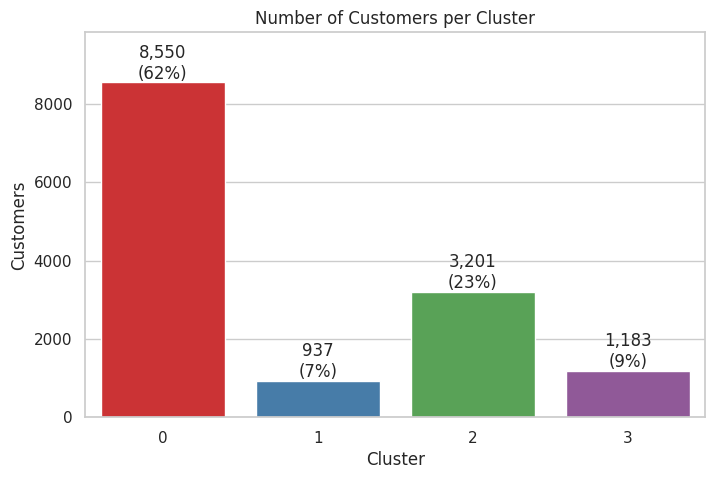

In [ ]:
counts = rfm["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, palette=palette)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v / counts.sum():.0%})", ha="center", va="bottom")
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster"); plt.ylabel("Customers")
plt.ylim(0, counts.max() * 1.15)
plt.show()

**Observation:** _Which cluster is largest? Is it also the most valuable?_

## 10. Insights and marketing recommendations

| Segment | Profile | Recommended marketing action |
|---|---|---|
| **Champions / Loyal** | Recent, frequent, large baskets | Loyalty rewards, VIP or early access to new products, referral programme. |
| **New / Promising** | Recent but few purchases | Welcome series, second-purchase incentive, product recommendations. |
| **At Risk** | Used to buy well but inactive lately | Win-back campaign with a personalised offer, reminder emails, feedback survey. |
| **Lost / Hibernating** | Long inactive, small baskets | Low-cost reactivation offer once; stop spending budget if no response. |

### Overall takeaways
1. _X% of customers account for Y% of items purchased, so protect that group first._
2. _The largest segment is ..., so the growth lever is moving them up a tier._
3. _Win-back of At Risk customers is cheaper than acquiring new ones._

### Limitations
- No price data, so Monetary is measured in items rather than currency.
- Segments use purchase behaviour only; demographics from `customer_details` were used to describe them, not to form them.